In [1]:
import xarray as xr
import numpy as np
from scipy import stats

In [2]:
ensemble = ['ens01', 'ens02', 'ens03', 'ens04', 'ens05', 'ens06', 'ens07', 'ens08', 'ens09', 'ens10', 'ens11', 'ens12', 'ens13', 'ens14', 'ens15', 'ens16', 'ens17', 'ens18', 'ens19', 'ens20', 'ens21', 'ens22', 'ens23', 'ens24', 'ens25',\
            'ens26', 'ens27', 'ens28', 'ens29', 'ens30', 'ens31', 'ens32', 'ens33', 'ens34', 'ens35', 'ens36', 'ens37', 'ens38', 'ens39', 'ens40', 'ens41', 'ens42', 'ens43', 'ens44', 'ens45', 'ens46', 'ens47', 'ens48', 'ens49', 'ens50']

In [3]:
def get_nat_trend(season):
    
    nat_mean_da = xr.open_dataarray(input_dir + 'means/' + 'ECHAM5_nat_'+season+'_tas_gaussian_ensMean.nc')
    
    ts = nat_mean_da.mean(['lat','lon']).values
    result = stats.linregress([i for i in range(len(ts))], ts)
    lin_regression = [i*result.slope + result.intercept for i in range(len(ts))]

    linreg_da = xr.DataArray(
        data=np.array(lin_regression),
        dims=["time"],
        coords=dict(
            time=nat_mean_da.time.values
        )
    )
    
    return(linreg_da)

In [4]:
input_dir = '/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/gaussian/tas/seasonal/'
output_dir = '/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/gaussian/tas/seasonal/remove_nat_trend/'

for scen in ['all','nat']:
    print(scen)
    for season in ['winter','spring','autumn','summer']:
        print(season)
        nat_trend = get_nat_trend(season)
        
        for mem in ensemble:
            
            mem_da = xr.open_dataarray(input_dir + 'ECHAM5_'+scen+'_'+season+'_tas_gaussian_'+mem+'.nc')
            
            detrended_da = mem_da - nat_trend
            
            detrended_da.to_netcdf(output_dir + 'ECHAM5_'+scen+'_'+season+'_tas_gaussian_nat_trend_removed_'+mem+'.nc')
            

all
winter
spring
autumn
summer
nat
winter
spring
autumn
summer


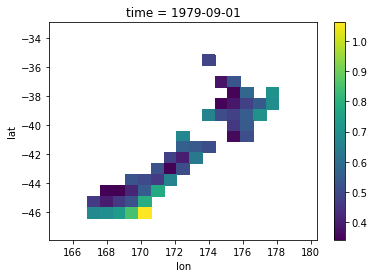

In [11]:
detrended_da.isel(time=0).plot()

In [5]:
'''
Create ensemble means
'''

path = '/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/gaussian/tas/seasonal/remove_nat_trend/'
    
for scen in ['all','nat']:

    for season in ['winter','spring','autumn','summer']:
        
        da_list = []
        
        for mem in ensemble:
            
            mem_da = xr.open_dataarray(path + 'ECHAM5_'+scen+'_'+season+'_tas_gaussian_nat_trend_removed_'+mem+'.nc')
            
            da_list.append(mem_da)

        ens_ds = xr.concat(da_list,dim='member')
        ens_ds['member']=ensemble
        
        # full ensemble mean
        ens_ds.mean('member').to_netcdf(path+'means/ECHAM5_'+scen+'_'+season+'_tas_gaussian_nat_trend_removed_'+"ensMean"+'.nc')
        
        # means without members
        for mem in ensemble:
            ens_ds.where(ens_ds.member != mem).mean('member').to_netcdf(path+'means/ECHAM5_'+scen+'_'+season+'_tas_gaussian_nat_trend_removed_'+"mean_sub_"+mem+'.nc')
